<a href="https://colab.research.google.com/github/vennelanalajam/myproject/blob/main/Pneumonia_Chest_X_Ray_Classification_using_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pneumionia Chest X-Rey Classification using CNN

# Step 1 : Problem Statement

Pneumonia Chest X-Rey Classification using CNN

# Project Objective

The main objective of this project is to build an Artificial Intelligence model that can classify chest X-rey images images as:

- NORMAL
- PNEUMONIA

This project uses:
- Deep Learning
- Convolutional Neural Networks (CNN)
- TensorFlow & Keras

The model learns patterns from chest X-ray images and predicts whether the patient has pneumonia or not.



## 📌 Why This Project?
Pneumonia is a serious lung infection. Detecting it early through X-ray images can help doctors provide faster treatment.

AI-based image classification can:
- Reduce manual effort
- Improve diagnosis speed
- Assist radiologists



## 📌 Technologies Used
- Python
- TensorFlow
- Keras
- Matplotlib
- Google Colab

# Step 2: Import Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

from tensorflow.keras.optimizers import Adam

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Step 3: Download Dataset Automatically

Instead of uploading ZIP files manually, we download the dataset directly inside Google Colab.

The dataset contains chest X-ray images of:
- NORMAL patients
- PNEUMONIA patients

After downloading, we extract the dataset.


In [2]:
# Code cell
# Download chest X-ray dataset
!wget https://data.mendeley.com/public-files/datasets/rscbjbr9sj/files/f9f93881-72a5-4884-bd99-3de95ff7503f/file_downloaded

print("Dataset Downloaded Successfully")


--2026-05-18 09:50:44--  https://data.mendeley.com/public-files/datasets/rscbjbr9sj/files/f9f93881-72a5-4884-bd99-3de95ff7503f/file_downloaded
Resolving data.mendeley.com (data.mendeley.com)... 162.159.130.86, 162.159.133.86
Connecting to data.mendeley.com (data.mendeley.com)|162.159.130.86|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1177 (1.1K) [application/json]
Saving to: ‘file_downloaded’

file_downloaded     100%[===================>]   1.15K  --.-KB/s    in 0s      

2026-05-18 09:50:45 (14.1 MB/s) - ‘file_downloaded’ saved [1177/1177]

Dataset Downloaded Successfully


# Step 4: Load Dataset

# Loading and Preprocessing Images

We use ImageDataGenerator for:
- Rescaling pixel values
- Loading images in batches
- Splitting training and validation data

### Why Rescaling?
Images contain pixel values from 0 to 255.

We divide by 255 so values become:
0 → 1

This improves model training.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
dataset_path = dataset_path = "/content/drive/MyDrive/ext_chest_xrey_ai project/Chest-Xray-2"
print("Dataset Path Connected Successfully")

Dataset Path Connected Successfully


In [5]:
dataset_path = "/content/drive/MyDrive/ext_chest_xrey_ai project/Chest-Xray-2"

# Image Preprocessing
datagen = ImageDataGenerator( rescale = 1./255, validation_split=0.2)

# Training dataset
train_data = datagen.flow_from_directory(
    dataset_path,
    target_size = (64,64),
    batch_size = 32,
    class_mode = "binary",
    subset = "training"
)

# validation dataset
val_data = datagen.flow_from_directory(
    dataset_path,
    target_size = (64,64),
    batch_size = 32,
    class_mode = "binary",
    subset = "validation"
)



Found 3008 images belonging to 1 classes.
Found 752 images belonging to 1 classes.


# Step 5 : Display Sample Images

Before training the model, we visualize some chest X-rey images.

This helps us:
- Verify dataset loading
- Understand images Structure
- Check Labels

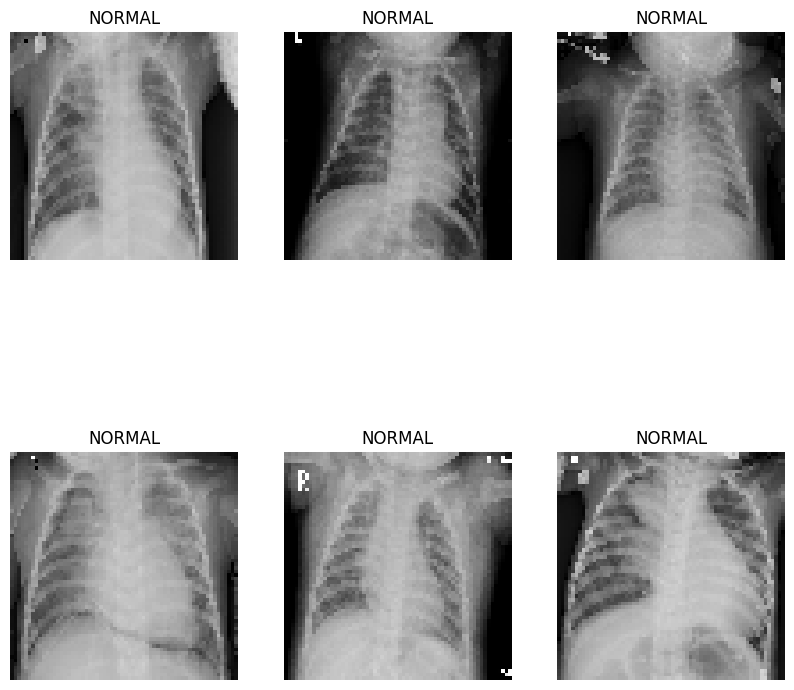

In [6]:
images, labels = next(train_data)

plt.figure(figsize = (10,10))

for i in range(6):
  plt.subplot(2,3,i+1)
  plt.imshow(images[i])

  if labels[i] == 1:
    plt.title("PNEUMONIA")
  else:
    plt.title("NORMAL")
  plt.axis("off")
plt.show()

# Step 6: Build CNN Model

# Building CNN Model

CNN (Convolutional Neural Network) is mainly used for image classification.

### Layers Used:

1. Conv2D
   - Extracts image features

2. MaxPooling2D
   - Reduces image size
   - Keeps important features

3. Flatten
   - Converts 2D data into 1D

4. Dense Layer
   - Fully connected neural network layer

5. Dropout
   - Prevents overfitting

6. Output Layer
   - Predicts NORMAL or PNEUMONIA


In [8]:
model = Sequential()

model.add(Conv2D(32,(3,3), activation="relu", input_shape=(64,64,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3,), activation = "relu"))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation="relu"))
model.add(Dropout(0.5))

model.add(Dense(1, activation = "sigmoid"))

model.compile(optimizer = "adam",loss = "binary_crossentropy",metrics = ['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,625,281 (6.20 MB)

 Trainable params: 1,625,281 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

# Step 7: Train the model

In this step, the CNN model learns patterns from chest X-ray images.

### Parameters:
- epochs → Number of training cycles
- validation_data → Testing during training
- batch_size → Number of images processed together

In [9]:
history = model.fit(train_data,
                    validation_data = val_data,
                    epochs = 5)

Epoch 1/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 883s 9s/step - accuracy: 0.9957 - loss: 0.0078 - val_accuracy: 1.0000 - val_loss: 1.8065e-26
Epoch 2/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 74s 785ms/step - accuracy: 1.0000 - loss: 1.6349e-17 - val_accuracy: 1.0000 - val_loss: 1.7885e-26
Epoch 3/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 69s 738ms/step - accuracy: 1.0000 - loss: 2.5092e-16 - val_accuracy: 1.0000 - val_loss: 1.7885e-26
Epoch 4/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 71s 752ms/step - accuracy: 1.0000 - loss: 1.0309e-17 - val_accuracy: 1.0000 - val_loss: 1.7885e-26
Epoch 5/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 70s 741ms/step - accuracy: 1.0000 - loss: 8.3377e-17 - val_accuracy: 1.0000 - val_loss: 1.7885e-26


# Step 8 : Plot Accuracy Graph

# Accuracy Graph

This graph shows:
- Training Accuracy
- Validation Accuracy

Higher accuracy indicates better model performance.

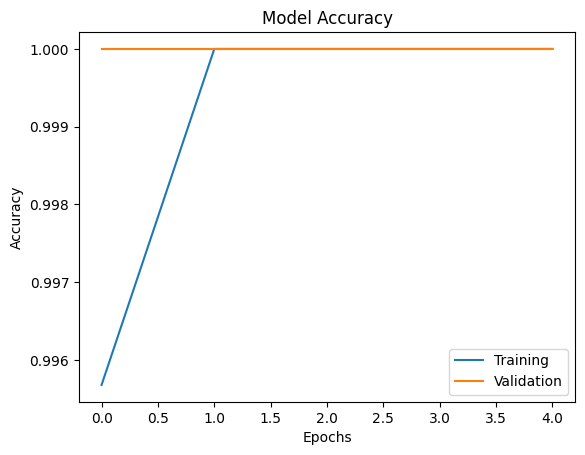

In [10]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend(["Training","Validation"])
plt.show()

# Step 9 : Plot Loss Graph

Loss indicates model error.

Lower loss means:
- Better predictions
- Improved learning

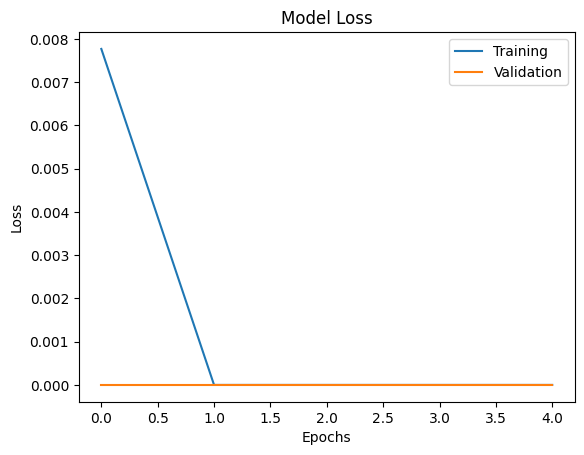

In [11]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend(["Training","Validation"])

plt.show()

# Step 10: Predict on New Image

Now the trained AI model predicts whether a chest X-ray image is:
- NORMAL
- PNEUMONIA

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
Prediction: NORMAL


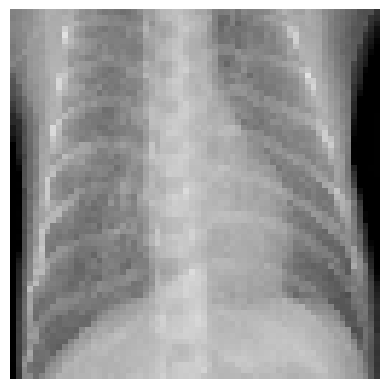

In [12]:
images, labels = next(val_data)

img = images[0]

prediction = model.predict(np.expand_dims(img, axis = 0))

plt.imshow(img)
plt.axis("off")

if prediction[0][0] > 0.5:
  print("prediction: PNEUMONIA")
else:
  print("Prediction: NORMAL")


# Step 11: Conclusion

# Conclusion

In this project, we successfully built a CNN-based Deep Learning model to classify chest X-ray images.

### Achievements:
- Loaded chest X-ray dataset
- Preprocessed image data
- Built CNN model
- Trained AI model
- Visualized accuracy and loss
- Predicted pneumonia from X-ray images

This project demonstrates how Artificial Intelligence can assist in medical image diagnosis.
